# Reuters 뉴스 기사 분류 실습

## 전체 코드 흐름

1. **라이브러리 불러오기**
   - NumPy와 Matplotlib으로 데이터 확인과 시각화를 수행한다.
   - PyTorch로 Dataset, DataLoader, LSTM 모델, 손실 함수, 최적화 함수를 구현한다.

2. **Reuters 뉴스 기사 데이터셋 불러오기**
   - Reuters 뉴스 데이터셋을 사용한다.
   - 실행 환경에 Reuters 로더가 있으면 해당 데이터를 사용한다.
   - 해당 로더가 없는 환경에서도 노트북이 중단되지 않도록 작은 예제 데이터를 자동으로 생성하는 안전 장치를 포함한다.

3. **데이터 구조 확인**
   - 뉴스 기사는 이미 단어가 정수 인덱스로 변환된 시퀀스 형태이다.
   - 라벨은 뉴스 카테고리를 의미하는 정수값이다.

4. **패딩 처리**
   - 길이가 서로 다른 뉴스 기사 시퀀스를 동일한 길이로 맞춘다.
   - PyTorch 모델은 같은 배치 안의 입력 길이가 같아야 하므로 패딩이 필요하다.

5. **PyTorch Dataset과 DataLoader 생성**
   - NumPy 배열을 PyTorch Tensor로 변환한다.
   - TensorDataset과 DataLoader를 사용하여 미니배치 학습이 가능하도록 구성한다.

6. **LSTM 기반 뉴스 분류 모델 구현**
   - Embedding 층에서 단어 인덱스를 밀집 벡터로 변환한다.
   - LSTM 층에서 단어 순서와 문맥 정보를 학습한다.
   - Dropout으로 과적합을 줄인다.
   - Linear 출력층에서 뉴스 카테고리별 점수를 출력한다.

7. **모델 학습**
   - CrossEntropyLoss를 사용하여 다중 클래스 분류 손실을 계산한다.
   - Adam Optimizer로 가중치를 업데이트한다.
   - 검증 정확도가 가장 좋은 모델을 파일로 저장한다.

8. **모델 평가와 예측**
   - 테스트 데이터로 손실과 정확도를 계산한다.
   - 샘플 뉴스 기사 또는 새 영어 문장을 입력하여 카테고리를 예측한다.



## 1. 기본 라이브러리 불러오기

In [1]:
# 운영체제와 파일 경로를 다루기 위해 os 모듈을 불러온다.
import os

# 실행 시간을 측정하거나 로그를 남길 때 사용할 수 있도록 time 모듈을 불러온다.
import time

# 난수 고정을 통해 매번 비슷한 실험 결과가 나오도록 random 모듈을 불러온다.
import random

# NumPy는 배열 처리와 수치 계산을 효율적으로 수행하기 위해 사용한다.
import numpy as np

# Matplotlib은 데이터 분포와 학습 결과를 그래프로 시각화하기 위해 사용한다.
import matplotlib.pyplot as plt

# PyTorch의 핵심 패키지로, Tensor 생성과 딥러닝 연산을 수행한다.
import torch

# torch.nn은 신경망 계층, 손실 함수, 활성화 함수 등을 제공한다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공한다.
import torch.optim as optim

# TensorDataset은 입력 Tensor와 정답 Tensor를 하나의 데이터셋으로 묶을 때 사용한다.
from torch.utils.data import TensorDataset

# DataLoader는 Dataset을 미니배치 단위로 나누어 학습 반복문에 공급한다.
from torch.utils.data import DataLoader

# 현재 설치된 PyTorch 버전을 출력하여 실행 환경을 확인한다.
print("PyTorch version:", torch.__version__)

# CUDA GPU를 사용할 수 있으면 GPU를 사용하고, 없으면 CPU를 사용하도록 장치를 설정한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 실제 학습에 사용할 장치를 출력한다.
print("사용 장치:", device)


PyTorch version: 2.11.0+cu128
사용 장치: cuda


## 2. 난수 고정 함수 작성

In [2]:
# 실험 결과의 재현성을 높이기 위해 난수를 고정하는 함수를 정의한다.
def set_seed(seed=42):
    # 파이썬 기본 random 모듈의 난수 시드를 고정한다.
    random.seed(seed)

    # NumPy에서 사용하는 난수 시드를 고정한다.
    np.random.seed(seed)

    # PyTorch CPU 연산에서 사용하는 난수 시드를 고정한다.
    torch.manual_seed(seed)

    # GPU가 사용 가능한 경우 모든 CUDA 장치의 난수 시드를 고정한다.
    torch.cuda.manual_seed_all(seed)

    # CuDNN 연산에서 가능한 한 결정론적 알고리즘을 사용하도록 설정한다.
    torch.backends.cudnn.deterministic = True

    # 입력 크기가 매번 달라질 때 자동 최적화를 수행하는 기능을 끈다.
    torch.backends.cudnn.benchmark = False


# 위에서 정의한 함수를 호출하여 현재 노트북의 난수를 고정한다.
set_seed(42)


## 3. Reuters 뉴스 기사 데이터셋 불러오기

In [3]:
# Reuters 데이터셋을 안전하게 불러오기 위한 함수를 정의한다.
def load_reuters_dataset(num_words=None, test_split=0.2):
    # TensorFlow/Keras Reuters 로더가 있는 환경에서는 원본 Reuters 데이터셋을 사용한다.
    try:
        # Keras에서 제공하는 Reuters 뉴스 기사 데이터셋 로더를 불러온다.
        from tensorflow.keras.datasets import reuters

        # 지정한 단어 수와 테스트 비율에 맞추어 Reuters 데이터셋을 불러온다.
        (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = reuters.load_data(
            num_words=num_words,
            test_split=test_split
        )

        # Reuters 단어 사전을 불러온다.
        word_to_index = reuters.get_word_index()

        # 실제 Reuters 데이터셋을 사용했다는 정보를 출력한다.
        print("TensorFlow/Keras Reuters 데이터셋을 불러왔습니다.")

        # 불러온 훈련 데이터, 테스트 데이터, 단어 사전을 반환한다.
        return (X_train_raw, y_train_raw), (X_test_raw, y_test_raw), word_to_index

    # TensorFlow가 없거나 Reuters 데이터를 불러오지 못해도 노트북이 중단되지 않도록 예외를 처리한다.
    except Exception as error:
        # 원본 데이터셋을 사용할 수 없다는 안내 문구를 출력한다.
        print("Reuters 데이터셋 로딩에 실패하여 예제용 작은 데이터를 생성합니다.")

        # 발생한 오류 내용을 출력하여 원인을 확인할 수 있도록 한다.
        print("오류 내용:", error)

        # 예제용 단어 사전을 직접 만든다.
        word_to_index = {
            "market": 1, "stock": 2, "profit": 3, "company": 4, "oil": 5,
            "trade": 6, "bank": 7, "money": 8, "team": 9, "game": 10,
            "win": 11, "minister": 12, "government": 13, "policy": 14,
            "technology": 15, "computer": 16, "software": 17
        }

        # 예제용 훈련 기사 시퀀스를 만든다.
        X_train_raw = [
            [1, 2, 3, 4, 8], [5, 6, 1, 2], [9, 10, 11], [12, 13, 14],
            [15, 16, 17], [1, 7, 8, 3], [9, 11, 10], [13, 12, 14]
        ]

        # 예제용 훈련 라벨을 만든다.
        y_train_raw = np.array([0, 0, 1, 2, 3, 0, 1, 2], dtype=np.int64)

        # 예제용 테스트 기사 시퀀스를 만든다.
        X_test_raw = [[2, 3, 4], [10, 11, 9], [16, 17, 15], [12, 14, 13]]

        # 예제용 테스트 라벨을 만든다.
        y_test_raw = np.array([0, 1, 3, 2], dtype=np.int64)

        # 예제용 데이터를 반환한다.
        return (X_train_raw, y_train_raw), (X_test_raw, y_test_raw), word_to_index


# Reuters 데이터셋을 전체 단어 사전 기준으로 한 번 불러와 데이터 구조를 확인한다.
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw), word_to_index = load_reuters_dataset(
    num_words=None,
    test_split=0.2
)

# 훈련용 뉴스 기사 개수를 출력한다.
print("훈련용 뉴스 기사 수:", len(X_train_raw))

# 테스트용 뉴스 기사 개수를 출력한다.
print("테스트용 뉴스 기사 수:", len(X_test_raw))

# 훈련 라벨과 테스트 라벨을 하나로 합쳐 전체 카테고리 수를 계산한다.
num_classes_raw = len(set(np.concatenate([np.array(y_train_raw), np.array(y_test_raw)])))

# 전체 뉴스 카테고리 수를 출력한다.
print("전체 뉴스 카테고리 수:", num_classes_raw)


2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TensorFlow/Keras Reuters 데이터셋을 불러왔습니다.
훈련용 뉴스 기사 수: 8982
테스트용 뉴스 기사 수: 2246
전체 뉴스 카테고리 수: 46


## 4. 뉴스 기사 데이터 구조 확인

In [4]:
# 첫 번째 훈련용 뉴스 기사는 이미 단어가 정수 인덱스로 변환된 리스트이다.
print("첫 번째 훈련용 뉴스 기사 정수 시퀀스:")

# 첫 번째 뉴스 기사 시퀀스를 출력한다.
print(X_train_raw[0])

# 첫 번째 훈련용 뉴스 기사의 라벨을 출력한다.
print("\n첫 번째 훈련용 뉴스 기사의 라벨:")

# 라벨은 뉴스 카테고리를 의미하는 정수값이다.
print(y_train_raw[0])

# 첫 번째 뉴스 기사에 포함된 토큰 개수를 출력한다.
print("\n첫 번째 훈련용 뉴스 기사의 길이:")

# len 함수로 첫 번째 뉴스 기사 시퀀스의 길이를 계산한다.
print(len(X_train_raw[0]))


첫 번째 훈련용 뉴스 기사 정수 시퀀스:
[1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]

첫 번째 훈련용 뉴스 기사의 라벨:
3

첫 번째 훈련용 뉴스 기사의 길이:
87


In [5]:
# 모든 훈련용 뉴스 기사 길이를 리스트로 만든다.
train_lengths = [len(sample) for sample in X_train_raw]

# 훈련용 뉴스 기사 중 가장 긴 기사의 길이를 계산한다.
max_train_length = max(train_lengths)

# 훈련용 뉴스 기사 길이의 평균을 계산한다.
mean_train_length = sum(train_lengths) / len(train_lengths)

# 뉴스 기사의 최대 길이를 출력한다.
print("뉴스 기사의 최대 길이:", max_train_length)

# 뉴스 기사의 평균 길이를 소수 둘째 자리까지 출력한다.
print("뉴스 기사의 평균 길이: {:.2f}".format(mean_train_length))


뉴스 기사의 최대 길이: 2376
뉴스 기사의 평균 길이: 145.54


## 5. 뉴스 기사 길이 분포 시각화

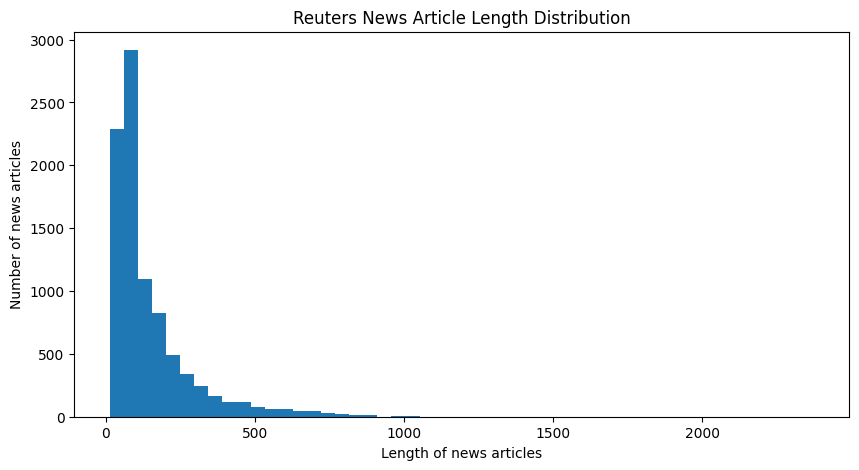

In [6]:
# 그래프 크기를 가로 10인치, 세로 5인치로 설정한다.
plt.figure(figsize=(10, 5))

# 훈련용 뉴스 기사 길이 분포를 히스토그램으로 출력한다.
plt.hist(train_lengths, bins=50)

# x축 이름을 설정한다.
plt.xlabel("Length of news articles")

# y축 이름을 설정한다.
plt.ylabel("Number of news articles")

# 그래프 제목을 설정한다.
plt.title("Reuters News Article Length Distribution")

# 그래프를 화면에 출력한다.
plt.show()


## 6. 라벨 분포 확인

In [7]:
# np.unique는 라벨 종류와 각 라벨의 등장 횟수를 함께 계산한다.
unique_labels, label_counts = np.unique(y_train_raw, return_counts=True)

# 라벨 번호와 빈도수를 2행 배열 형태로 묶는다.
label_distribution = np.asarray((unique_labels, label_counts))

# 라벨별 빈도수 정보를 출력한다.
print("각 라벨에 대한 빈도수:")

# 라벨 분포 배열을 출력한다.
print(label_distribution)


각 라벨에 대한 빈도수:
[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45]
 [  55  432   74 3159 1949   17   48   16  139  101  124  390   49  172
    26   20  444   39   66  549  269  100   15   41   62   92   24   15
    48   19   45   39   32   11   50   10   49   19   19   24   36   30
    13   21   12   18]]


## 7. 단어 사전과 기사 복원 확인

In [8]:
# 단어 사전의 전체 단어 개수를 출력한다.
print("Reuters 단어 사전 크기:", len(word_to_index))

# 단어 사전 중 앞부분 일부만 확인하기 위해 10개 항목을 출력한다.
print("단어 사전 샘플 10개:")

# 딕셔너리 항목을 리스트로 바꾼 후 앞의 10개만 출력한다.
print(list(word_to_index.items())[:10])


Reuters 단어 사전 크기: 30979
단어 사전 샘플 10개:
[('mdbl', 10996), ('fawc', 16260), ('degussa', 12089), ('woods', 8803), ('hanging', 13796), ('localized', 20672), ('sation', 20673), ('chanthaburi', 20675), ('refunding', 10997), ('hermann', 8804)]


In [9]:
# 정수 인덱스를 다시 단어로 바꾸기 위한 빈 딕셔너리를 생성한다.
index_to_word = {}

# Reuters 데이터셋에서는 0, 1, 2가 특수 토큰으로 사용되므로 실제 단어 인덱스에 3을 더해 저장한다.
for word, index in word_to_index.items():
    # 현재 단어의 실제 시퀀스 인덱스를 key로 저장하고, 단어를 value로 저장한다.
    index_to_word[index + 3] = word

# 패딩을 의미하는 특수 토큰을 0번 인덱스에 저장한다.
index_to_word[0] = "<pad>"

# 문장 시작을 의미하는 특수 토큰을 1번 인덱스에 저장한다.
index_to_word[1] = "<sos>"

# 사전에 없는 단어를 의미하는 특수 토큰을 2번 인덱스에 저장한다.
index_to_word[2] = "<unk>"

# 사용하지 않는 예비 특수 토큰을 3번 인덱스에 저장한다.
index_to_word[3] = "<unused>"

# 4번 인덱스가 존재할 때만 단어를 출력한다.
print("4번 인덱스 단어:", index_to_word.get(4, "<없음>"))

# 5번 인덱스가 존재할 때만 단어를 출력한다.
print("5번 인덱스 단어:", index_to_word.get(5, "<없음>"))


4번 인덱스 단어: the
5번 인덱스 단어: of


In [10]:
# 첫 번째 훈련용 뉴스 기사에 포함된 정수 인덱스를 단어로 변환한다.
decoded_article = " ".join([index_to_word.get(index, "<unk>") for index in X_train_raw[0]])

# 복원된 첫 번째 뉴스 기사를 출력한다.
print("첫 번째 뉴스 기사 복원 결과:")

# 복원된 텍스트를 출력한다.
print(decoded_article)


첫 번째 뉴스 기사 복원 결과:
<sos> mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


## 8. 하이퍼파라미터 설정

In [11]:
# vocab_size는 모델에서 사용할 상위 단어 개수를 의미한다.
vocab_size = 1000

# max_len은 모든 뉴스 기사 길이를 몇 개 토큰으로 맞출지 결정하는 값이다.
max_len = 100

# embedding_dim은 각 단어를 몇 차원의 밀집 벡터로 표현할지 결정한다.
embedding_dim = 128

# hidden_units는 LSTM 내부 은닉 상태의 차원 수를 의미한다.
hidden_units = 128

# dropout_rate는 Dropout에서 무작위로 비활성화할 뉴런 비율이다.
dropout_rate = 0.3

# batch_size는 한 번의 가중치 업데이트에 사용할 데이터 개수이다.
batch_size = 128

# epochs는 전체 훈련 데이터를 최대 몇 번 반복해서 학습할지 결정한다.
epochs = 5

# learning_rate는 Adam Optimizer가 가중치를 조정할 때 사용하는 학습률이다.
learning_rate = 0.001

# patience는 검증 손실이 개선되지 않아도 기다릴 에포크 수이다.
patience = 3

# 설정한 하이퍼파라미터를 출력한다.
print("vocab_size:", vocab_size)
print("max_len:", max_len)
print("embedding_dim:", embedding_dim)
print("hidden_units:", hidden_units)
print("batch_size:", batch_size)
print("epochs:", epochs)


vocab_size: 1000
max_len: 100
embedding_dim: 128
hidden_units: 128
batch_size: 128
epochs: 5


## 9. PyTorch용 패딩 함수 작성

In [12]:
# 길이가 서로 다른 정수 시퀀스를 동일한 길이로 맞추는 패딩 함수를 정의한다.
def pad_sequences_torch_style(sequences, maxlen, padding="pre", truncating="pre", value=0):
    # 패딩 처리된 결과를 저장할 리스트를 생성한다.
    padded_sequences = []

    # 입력으로 받은 각 정수 시퀀스를 하나씩 처리한다.
    for sequence in sequences:
        # 원본 시퀀스가 리스트가 아닐 수도 있으므로 리스트로 변환한다.
        sequence = list(sequence)

        # 시퀀스 길이가 maxlen보다 길면 일부 토큰을 잘라낸다.
        if len(sequence) > maxlen:
            # truncating이 pre이면 앞쪽 토큰을 제거하고 뒤쪽 maxlen개만 남긴다.
            if truncating == "pre":
                sequence = sequence[-maxlen:]

            # truncating이 post이면 뒤쪽 토큰을 제거하고 앞쪽 maxlen개만 남긴다.
            else:
                sequence = sequence[:maxlen]

        # 시퀀스 길이가 maxlen보다 짧으면 부족한 길이를 계산한다.
        pad_length = maxlen - len(sequence)

        # padding이 pre이면 앞쪽에 0을 채운다.
        if padding == "pre":
            padded_sequence = [value] * pad_length + sequence

        # padding이 post이면 뒤쪽에 0을 채운다.
        else:
            padded_sequence = sequence + [value] * pad_length

        # 패딩이 완료된 시퀀스를 결과 리스트에 추가한다.
        padded_sequences.append(padded_sequence)

    # 패딩 결과를 NumPy 정수 배열로 변환하여 반환한다.
    return np.array(padded_sequences, dtype=np.int64)


## 10. 모델 입력 데이터 준비

In [13]:
# Reuters 데이터셋을 상위 vocab_size개 단어만 사용하도록 다시 불러온다.
(X_train, y_train), (X_test, y_test), word_to_index = load_reuters_dataset(
    num_words=vocab_size,
    test_split=0.2
)

# 훈련용 뉴스 기사 길이를 max_len으로 맞춘다.
X_train = pad_sequences_torch_style(
    X_train,
    maxlen=max_len,
    padding="pre",
    truncating="pre",
    value=0
)

# 테스트용 뉴스 기사 길이를 max_len으로 맞춘다.
X_test = pad_sequences_torch_style(
    X_test,
    maxlen=max_len,
    padding="pre",
    truncating="pre",
    value=0
)

# 훈련 라벨을 NumPy 정수 배열로 변환한다.
y_train = np.array(y_train, dtype=np.int64)

# 테스트 라벨을 NumPy 정수 배열로 변환한다.
y_test = np.array(y_test, dtype=np.int64)

# 훈련 라벨과 테스트 라벨을 합쳐 전체 클래스 개수를 계산한다.
num_classes = int(max(np.max(y_train), np.max(y_test)) + 1)

# 패딩 후 훈련 데이터의 형태를 출력한다.
print("X_train shape:", X_train.shape)

# 패딩 후 테스트 데이터의 형태를 출력한다.
print("X_test shape:", X_test.shape)

# 훈련 라벨의 형태를 출력한다.
print("y_train shape:", y_train.shape)

# 테스트 라벨의 형태를 출력한다.
print("y_test shape:", y_test.shape)

# 클래스 개수를 출력한다.
print("num_classes:", num_classes)


TensorFlow/Keras Reuters 데이터셋을 불러왔습니다.
X_train shape: (8982, 100)
X_test shape: (2246, 100)
y_train shape: (8982,)
y_test shape: (2246,)
num_classes: 46


## 11. NumPy 배열을 PyTorch Tensor로 변환

In [14]:
# 훈련 입력 데이터를 PyTorch LongTensor로 변환한다.
X_train_tensor = torch.tensor(X_train, dtype=torch.long)

# 훈련 라벨 데이터를 PyTorch LongTensor로 변환한다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

# 테스트 입력 데이터를 PyTorch LongTensor로 변환한다.
X_test_tensor = torch.tensor(X_test, dtype=torch.long)

# 테스트 라벨 데이터를 PyTorch LongTensor로 변환한다.
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 훈련 입력 Tensor의 형태를 출력한다.
print("X_train_tensor shape:", X_train_tensor.shape)

# 훈련 라벨 Tensor의 형태를 출력한다.
print("y_train_tensor shape:", y_train_tensor.shape)

# 테스트 입력 Tensor의 형태를 출력한다.
print("X_test_tensor shape:", X_test_tensor.shape)

# 테스트 라벨 Tensor의 형태를 출력한다.
print("y_test_tensor shape:", y_test_tensor.shape)


X_train_tensor shape: torch.Size([8982, 100])
y_train_tensor shape: torch.Size([8982])
X_test_tensor shape: torch.Size([2246, 100])
y_test_tensor shape: torch.Size([2246])


## 12. Dataset과 DataLoader 생성

In [15]:
# 훈련 입력 Tensor와 훈련 라벨 Tensor를 하나의 Dataset으로 묶는다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# 테스트 입력 Tensor와 테스트 라벨 Tensor를 하나의 Dataset으로 묶는다.
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 훈련 DataLoader는 데이터를 batch_size 단위로 나누고 매 에포크마다 순서를 섞는다.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# 테스트 DataLoader는 평가용이므로 순서를 섞지 않는다.
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 훈련 미니배치 개수를 출력한다.
print("훈련 미니배치 수:", len(train_loader))

# 테스트 미니배치 개수를 출력한다.
print("테스트 미니배치 수:", len(test_loader))


훈련 미니배치 수: 71
테스트 미니배치 수: 18


## 13. PyTorch LSTM 뉴스 분류 모델 구현

In [16]:
# PyTorch nn.Module을 상속하여 LSTM 기반 뉴스 분류 모델 클래스를 정의한다.
class ReutersLSTMClassifier(nn.Module):
    # 모델에서 사용할 계층과 하이퍼파라미터를 초기화한다.
    def __init__(self, vocab_size, embedding_dim, hidden_units, num_classes, dropout_rate):
        # 부모 클래스인 nn.Module의 초기화 함수를 실행한다.
        super().__init__()

        # Embedding 층은 정수 단어 인덱스를 학습 가능한 밀집 벡터로 변환한다.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # LSTM 층은 단어 순서와 문맥 정보를 학습한다.
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_units,
            batch_first=True
        )

        # Dropout 층은 일부 뉴런 출력을 무작위로 0으로 만들어 과적합을 줄인다.
        self.dropout = nn.Dropout(
            p=dropout_rate
        )

        # Linear 층은 LSTM 출력 특징을 뉴스 카테고리 개수만큼의 점수로 변환한다.
        self.fc = nn.Linear(
            in_features=hidden_units,
            out_features=num_classes
        )

    # 입력 데이터가 모델을 통과하는 순전파 과정을 정의한다.
    def forward(self, x):
        # 입력 x의 형태는 [배치 크기, 문장 길이]이다.
        embedded = self.embedding(x)

        # embedded의 형태는 [배치 크기, 문장 길이, 임베딩 차원]이다.
        lstm_output, (hidden_state, cell_state) = self.lstm(embedded)

        # hidden_state의 마지막 층 은닉 상태를 가져온다.
        last_hidden = hidden_state[-1]

        # Dropout을 적용하여 과적합을 완화한다.
        dropped = self.dropout(last_hidden)

        # 최종 출력층을 통과시켜 각 클래스에 대한 점수를 계산한다.
        logits = self.fc(dropped)

        # CrossEntropyLoss는 softmax를 내부적으로 처리하므로 확률이 아닌 logits를 반환한다.
        return logits


# LSTM 뉴스 분류 모델 객체를 생성한다.
model = ReutersLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_units=hidden_units,
    num_classes=num_classes,
    dropout_rate=dropout_rate
)

# 모델을 CPU 또는 GPU 장치로 이동한다.
model = model.to(device)

# 생성된 모델 구조를 출력한다.
print(model)


ReutersLSTMClassifier(
  (embedding): Embedding(1000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=46, bias=True)
)


## 14. 손실 함수와 최적화 알고리즘 설정

In [17]:
# CrossEntropyLoss는 다중 클래스 분류에서 사용하는 대표적인 손실 함수이다.
criterion = nn.CrossEntropyLoss()

# Adam Optimizer는 학습률을 적응적으로 조정하면서 모델 가중치를 업데이트한다.
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

# 가장 좋은 모델을 저장할 폴더를 생성한다.
os.makedirs("models", exist_ok=True)

# 가장 좋은 모델 가중치를 저장할 파일 경로를 지정한다.
best_model_path = os.path.join("models", "best_reuters_lstm_torch.pt")

# 최적 검증 손실을 무한대로 초기화한다.
best_val_loss = float("inf")

# Early Stopping을 위해 검증 손실이 개선되지 않은 에포크 수를 저장한다.
epochs_without_improvement = 0


## 15. 정확도 계산 함수 작성

In [18]:
# 모델 출력과 정답 라벨을 받아 정확도를 계산하는 함수를 정의한다.
def calculate_accuracy(logits, labels):
    # logits에서 가장 큰 값을 갖는 클래스 인덱스를 예측 라벨로 선택한다.
    predictions = torch.argmax(logits, dim=1)

    # 예측 라벨과 실제 라벨이 같은지 비교한다.
    correct = (predictions == labels).sum().item()

    # 전체 라벨 개수를 계산한다.
    total = labels.size(0)

    # 맞힌 개수를 전체 개수로 나누어 정확도를 계산한다.
    accuracy = correct / total

    # 계산된 정확도를 반환한다.
    return accuracy


## 16. 학습 함수 작성

In [19]:
# 한 에포크 동안 모델을 학습하는 함수를 정의한다.
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # 모델을 학습 모드로 전환한다.
    model.train()

    # 에포크 전체 손실 합계를 저장할 변수를 초기화한다.
    total_loss = 0.0

    # 에포크 전체 정확도 합계를 저장할 변수를 초기화한다.
    total_accuracy = 0.0

    # DataLoader에서 미니배치를 하나씩 가져온다.
    for batch_inputs, batch_labels in data_loader:
        # 입력 데이터를 CPU 또는 GPU 장치로 이동한다.
        batch_inputs = batch_inputs.to(device)

        # 정답 라벨을 CPU 또는 GPU 장치로 이동한다.
        batch_labels = batch_labels.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화한다.
        optimizer.zero_grad()

        # 모델에 입력 데이터를 넣어 클래스별 점수 logits를 계산한다.
        logits = model(batch_inputs)

        # 모델 출력과 정답 라벨을 비교하여 손실을 계산한다.
        loss = criterion(logits, batch_labels)

        # 손실을 기준으로 역전파를 수행하여 기울기를 계산한다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 가중치를 업데이트한다.
        optimizer.step()

        # 현재 미니배치 손실에 데이터 개수를 곱해 누적한다.
        total_loss += loss.item() * batch_inputs.size(0)

        # 현재 미니배치 정확도를 계산한다.
        batch_accuracy = calculate_accuracy(logits, batch_labels)

        # 현재 미니배치 정확도에 데이터 개수를 곱해 누적한다.
        total_accuracy += batch_accuracy * batch_inputs.size(0)

    # 전체 평균 손실을 계산한다.
    average_loss = total_loss / len(data_loader.dataset)

    # 전체 평균 정확도를 계산한다.
    average_accuracy = total_accuracy / len(data_loader.dataset)

    # 평균 손실과 평균 정확도를 반환한다.
    return average_loss, average_accuracy


## 17. 평가 함수 작성

In [20]:
# 모델을 평가하는 함수를 정의한다.
def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드로 전환한다.
    model.eval()

    # 평가 전체 손실 합계를 저장할 변수를 초기화한다.
    total_loss = 0.0

    # 평가 전체 정확도 합계를 저장할 변수를 초기화한다.
    total_accuracy = 0.0

    # 평가 단계에서는 기울기를 계산하지 않도록 설정한다.
    with torch.no_grad():
        # DataLoader에서 미니배치를 하나씩 가져온다.
        for batch_inputs, batch_labels in data_loader:
            # 입력 데이터를 CPU 또는 GPU 장치로 이동한다.
            batch_inputs = batch_inputs.to(device)

            # 정답 라벨을 CPU 또는 GPU 장치로 이동한다.
            batch_labels = batch_labels.to(device)

            # 모델에 입력 데이터를 넣어 클래스별 점수 logits를 계산한다.
            logits = model(batch_inputs)

            # 모델 출력과 정답 라벨을 비교하여 손실을 계산한다.
            loss = criterion(logits, batch_labels)

            # 현재 미니배치 손실에 데이터 개수를 곱해 누적한다.
            total_loss += loss.item() * batch_inputs.size(0)

            # 현재 미니배치 정확도를 계산한다.
            batch_accuracy = calculate_accuracy(logits, batch_labels)

            # 현재 미니배치 정확도에 데이터 개수를 곱해 누적한다.
            total_accuracy += batch_accuracy * batch_inputs.size(0)

    # 전체 평균 손실을 계산한다.
    average_loss = total_loss / len(data_loader.dataset)

    # 전체 평균 정확도를 계산한다.
    average_accuracy = total_accuracy / len(data_loader.dataset)

    # 평균 손실과 평균 정확도를 반환한다.
    return average_loss, average_accuracy


## 18. PyTorch 모델 학습 실행

In [21]:
# 학습 과정에서 발생한 훈련 손실을 저장할 리스트를 생성한다.
train_losses = []

# 학습 과정에서 발생한 검증 손실을 저장할 리스트를 생성한다.
val_losses = []

# 학습 과정에서 발생한 훈련 정확도를 저장할 리스트를 생성한다.
train_accuracies = []

# 학습 과정에서 발생한 검증 정확도를 저장할 리스트를 생성한다.
val_accuracies = []

# 전체 학습 시작 시간을 기록한다.
start_time = time.time()

# 지정한 에포크 수만큼 학습을 반복한다.
for epoch in range(1, epochs + 1):
    # 한 에포크 동안 훈련 데이터를 사용하여 모델을 학습한다.
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # 한 에포크가 끝난 뒤 테스트 데이터를 사용하여 모델을 평가한다.
    val_loss, val_accuracy = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    # 현재 에포크의 훈련 손실을 리스트에 저장한다.
    train_losses.append(train_loss)

    # 현재 에포크의 검증 손실을 리스트에 저장한다.
    val_losses.append(val_loss)

    # 현재 에포크의 훈련 정확도를 리스트에 저장한다.
    train_accuracies.append(train_accuracy)

    # 현재 에포크의 검증 정확도를 리스트에 저장한다.
    val_accuracies.append(val_accuracy)

    # 현재 에포크의 학습 결과를 출력한다.
    print(
        f"Epoch [{epoch}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # 검증 손실이 이전 최적값보다 작으면 모델을 저장한다.
    if val_loss < best_val_loss:
        # 최적 검증 손실 값을 현재 검증 손실로 갱신한다.
        best_val_loss = val_loss

        # 개선되지 않은 에포크 수를 0으로 초기화한다.
        epochs_without_improvement = 0

        # 현재 모델의 가중치와 설정 정보를 파일로 저장한다.
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "vocab_size": vocab_size,
                "embedding_dim": embedding_dim,
                "hidden_units": hidden_units,
                "num_classes": num_classes,
                "dropout_rate": dropout_rate,
                "max_len": max_len
            },
            best_model_path
        )

        # 모델이 저장되었음을 출력한다.
        print("검증 손실이 개선되어 모델을 저장했습니다:", best_model_path)

    # 검증 손실이 개선되지 않은 경우 처리한다.
    else:
        # 개선되지 않은 에포크 수를 1 증가시킨다.
        epochs_without_improvement += 1

        # 개선되지 않은 횟수를 출력한다.
        print("검증 손실 미개선 횟수:", epochs_without_improvement)

        # 개선되지 않은 횟수가 patience 이상이면 학습을 조기 종료한다.
        if epochs_without_improvement >= patience:
            # Early Stopping 안내 문구를 출력한다.
            print("Early Stopping 조건을 만족하여 학습을 중단합니다.")

            # 학습 반복문을 종료한다.
            break

# 전체 학습 종료 시간을 기록한다.
end_time = time.time()

# 전체 학습 시간을 출력한다.
print("전체 학습 시간: {:.2f}초".format(end_time - start_time))


Epoch [1/5] Train Loss: 2.5019 Train Acc: 0.3759 Val Loss: 2.0715 Val Acc: 0.4929
검증 손실이 개선되어 모델을 저장했습니다: models/best_reuters_lstm_torch.pt
Epoch [2/5] Train Loss: 2.0641 Train Acc: 0.4901 Val Loss: 2.0136 Val Acc: 0.5009
검증 손실이 개선되어 모델을 저장했습니다: models/best_reuters_lstm_torch.pt
Epoch [3/5] Train Loss: 1.9239 Train Acc: 0.5191 Val Loss: 1.7995 Val Acc: 0.5401
검증 손실이 개선되어 모델을 저장했습니다: models/best_reuters_lstm_torch.pt
Epoch [4/5] Train Loss: 1.7692 Train Acc: 0.5452 Val Loss: 1.7387 Val Acc: 0.5557
검증 손실이 개선되어 모델을 저장했습니다: models/best_reuters_lstm_torch.pt
Epoch [5/5] Train Loss: 1.8130 Train Acc: 0.5370 Val Loss: 2.0857 Val Acc: 0.3851
검증 손실 미개선 횟수: 1
전체 학습 시간: 3.35초


## 19. 학습 결과 시각화

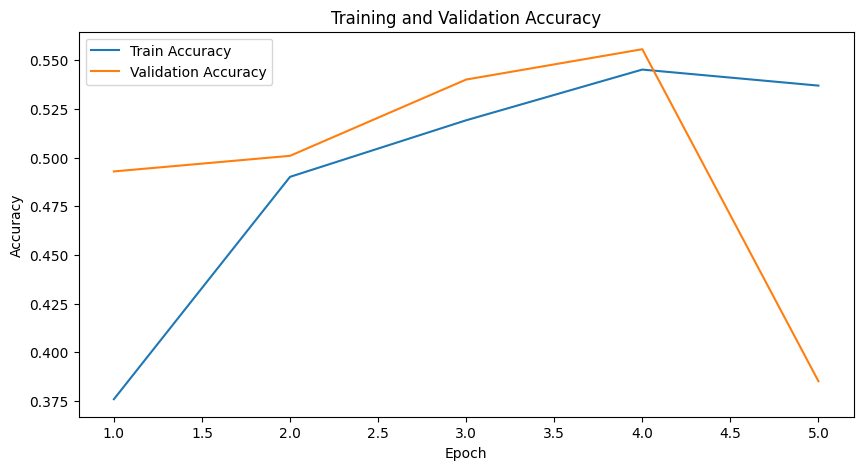

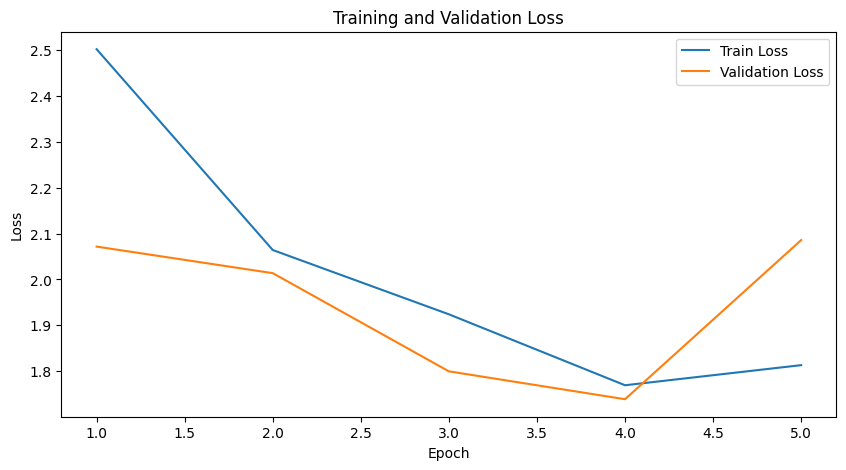

In [22]:
# 에포크 번호를 1부터 시작하는 리스트로 생성한다.
epochs_range = range(1, len(train_accuracies) + 1)

# 그래프 크기를 설정한다.
plt.figure(figsize=(10, 5))

# 훈련 정확도 그래프를 그린다.
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")

# 검증 정확도 그래프를 그린다.
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Accuracy")

# 그래프 제목을 설정한다.
plt.title("Training and Validation Accuracy")

# 범례를 표시한다.
plt.legend()

# 그래프를 출력한다.
plt.show()

# 그래프 크기를 설정한다.
plt.figure(figsize=(10, 5))

# 훈련 손실 그래프를 그린다.
plt.plot(epochs_range, train_losses, label="Train Loss")

# 검증 손실 그래프를 그린다.
plt.plot(epochs_range, val_losses, label="Validation Loss")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Loss")

# 그래프 제목을 설정한다.
plt.title("Training and Validation Loss")

# 범례를 표시한다.
plt.legend()

# 그래프를 출력한다.
plt.show()


## 20. 저장된 최적 모델 불러오기

In [23]:
# 저장된 최적 모델 파일이 존재하는지 확인한다.
if os.path.exists(best_model_path):
    # 저장된 체크포인트 파일을 현재 장치 기준으로 불러온다.
    checkpoint = torch.load(best_model_path, map_location=device)

    # 체크포인트에 저장된 설정값으로 동일한 구조의 모델 객체를 생성한다.
    loaded_model = ReutersLSTMClassifier(
        vocab_size=checkpoint["vocab_size"],
        embedding_dim=checkpoint["embedding_dim"],
        hidden_units=checkpoint["hidden_units"],
        num_classes=checkpoint["num_classes"],
        dropout_rate=checkpoint["dropout_rate"]
    )

    # 생성한 모델을 현재 장치로 이동한다.
    loaded_model = loaded_model.to(device)

    # 저장된 가중치를 모델에 적용한다.
    loaded_model.load_state_dict(checkpoint["model_state_dict"])

    # 모델 로딩 완료 메시지를 출력한다.
    print("저장된 최적 모델을 불러왔습니다.")

# 저장된 파일이 없는 경우 현재 학습된 모델을 그대로 사용한다.
else:
    # 현재 메모리에 있는 모델을 loaded_model 변수에 할당한다.
    loaded_model = model

    # 저장 파일이 없다는 안내 메시지를 출력한다.
    print("저장된 모델이 없어 현재 모델을 사용합니다.")


저장된 최적 모델을 불러왔습니다.


## 21. 테스트 데이터 최종 평가

In [24]:
# 불러온 모델을 사용하여 테스트 데이터의 손실과 정확도를 계산한다.
test_loss, test_accuracy = evaluate(
    model=loaded_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

# 테스트 손실을 출력한다.
print("테스트 손실: {:.4f}".format(test_loss))

# 테스트 정확도를 출력한다.
print("테스트 정확도: {:.4f}".format(test_accuracy))


테스트 손실: 1.7387
테스트 정확도: 0.5557


## 22. 테스트 기사 하나 예측하기

In [25]:
# 테스트 데이터 중 첫 번째 뉴스 기사를 하나 선택한다.
sample_article = X_test_tensor[0:1]

# 선택한 뉴스 기사의 실제 라벨을 가져온다.
true_label = int(y_test_tensor[0].item())

# 모델을 평가 모드로 전환한다.
loaded_model.eval()

# 예측 단계에서는 기울기를 계산하지 않도록 설정한다.
with torch.no_grad():
    # 샘플 기사를 현재 장치로 이동한다.
    sample_article_device = sample_article.to(device)

    # 모델을 사용하여 카테고리별 점수를 계산한다.
    logits = loaded_model(sample_article_device)

    # softmax를 적용하여 카테고리별 확률로 변환한다.
    probabilities = torch.softmax(logits, dim=1)

    # 가장 확률이 높은 카테고리 번호를 예측 라벨로 선택한다.
    predicted_label = int(torch.argmax(probabilities, dim=1).item())

    # 가장 높은 예측 확률값을 가져온다.
    predicted_probability = float(torch.max(probabilities).item())

# 실제 라벨을 출력한다.
print("실제 라벨:", true_label)

# 예측 라벨을 출력한다.
print("예측 라벨:", predicted_label)

# 예측 확률을 출력한다.
print("예측 확률: {:.4f}".format(predicted_probability))


실제 라벨: 3
예측 라벨: 4
예측 확률: 0.6754


## 23. 새 영어 문장 입력 후 카테고리 예측

In [26]:
# 새 문장을 Reuters 단어 사전 기준의 정수 시퀀스로 바꾸는 함수를 정의한다.
def encode_new_text(text, word_to_index, vocab_size=1000, max_len=100):
    # 입력 문장을 소문자로 변환하고 공백 기준으로 단어를 나눈다.
    words = text.lower().split()

    # Reuters 데이터셋의 문장 시작 토큰 인덱스 1을 먼저 넣는다.
    encoded = [1]

    # 입력 문장의 각 단어를 하나씩 확인한다.
    for word in words:
        # 단어가 Reuters 단어 사전에 있으면 해당 인덱스에 3을 더해 실제 시퀀스 인덱스로 변환한다.
        index = word_to_index.get(word, 2) + 3

        # 인덱스가 vocab_size보다 작으면 모델이 아는 단어로 처리한다.
        if index < vocab_size:
            # 변환된 단어 인덱스를 리스트에 추가한다.
            encoded.append(index)

        # vocab_size 범위를 벗어난 단어는 사전에 없는 단어로 처리한다.
        else:
            # 사전에 없는 단어를 의미하는 2번 인덱스를 추가한다.
            encoded.append(2)

    # 새 문장도 모델 입력 길이와 같도록 패딩한다.
    padded = pad_sequences_torch_style(
        [encoded],
        maxlen=max_len,
        padding="pre",
        truncating="pre",
        value=0
    )

    # 패딩된 정수 시퀀스를 PyTorch LongTensor로 변환한다.
    tensor = torch.tensor(padded, dtype=torch.long)

    # 변환된 Tensor를 반환한다.
    return tensor


# 새 영어 뉴스 문장을 입력하면 카테고리를 예측하는 함수를 정의한다.
def predict_news_category(text, model, word_to_index, vocab_size=1000, max_len=100, device="cpu"):
    # 입력 문장을 모델 입력 형식의 Tensor로 변환한다.
    input_tensor = encode_new_text(
        text=text,
        word_to_index=word_to_index,
        vocab_size=vocab_size,
        max_len=max_len
    )

    # 입력 Tensor를 CPU 또는 GPU 장치로 이동한다.
    input_tensor = input_tensor.to(device)

    # 모델을 평가 모드로 전환한다.
    model.eval()

    # 예측 단계에서는 기울기를 계산하지 않는다.
    with torch.no_grad():
        # 모델을 사용하여 클래스별 점수를 계산한다.
        logits = model(input_tensor)

        # softmax를 적용하여 클래스별 확률로 변환한다.
        probabilities = torch.softmax(logits, dim=1)

        # 가장 높은 확률을 갖는 클래스 번호를 예측 라벨로 선택한다.
        predicted_label = int(torch.argmax(probabilities, dim=1).item())

        # 가장 높은 확률값을 가져온다.
        predicted_probability = float(torch.max(probabilities).item())

    # 예측 라벨과 예측 확률을 반환한다.
    return predicted_label, predicted_probability


# 예측해 볼 새 영어 뉴스 문장을 작성한다.
new_text = "stock market profit company trade bank money"

# 새 문장의 카테고리를 예측한다.
predicted_label, predicted_probability = predict_news_category(
    text=new_text,
    model=loaded_model,
    word_to_index=word_to_index,
    vocab_size=vocab_size,
    max_len=max_len,
    device=device
)

# 입력 문장을 출력한다.
print("입력 문장:", new_text)

# 예측 라벨을 출력한다.
print("예측 라벨:", predicted_label)

# 예측 확률을 출력한다.
print("예측 확률: {:.4f}".format(predicted_probability))


입력 문장: stock market profit company trade bank money
예측 라벨: 3
예측 확률: 0.0776


## 24. 선택 사항: 한국어 사용자 사전 형태소 분석 확인

In [27]:
# customized_konlpy 설치 여부와 실행 가능 여부를 안전하게 확인하기 위해 try-except를 사용한다.
try:
    # customized_konlpy의 Twitter 형태소 분석기를 불러온다.
    from ckonlpy.tag import Twitter

    # Twitter 형태소 분석기 객체를 생성한다.
    twitter = Twitter()

    # 사용자 사전 추가 전 형태소 분석 결과를 출력한다.
    print("사용자 사전 추가 전:")

    # 기본 형태소 분석 결과를 출력한다.
    print(twitter.morphs("은경이는 사무실로 갔습니다."))

    # 사용자 사전에 '은경이'라는 단어를 명사로 추가한다.
    twitter.add_dictionary("은경이", "Noun")

    # 사용자 사전 추가 후 형태소 분석 결과를 출력한다.
    print("\n사용자 사전 추가 후:")

    # 사용자 사전이 반영된 형태소 분석 결과를 출력한다.
    print(twitter.morphs("은경이는 사무실로 갔습니다."))

# customized_konlpy가 없거나 Java 환경 문제가 있으면 노트북 실행이 중단되지 않도록 처리한다.
except Exception as error:
    # 선택 사항 코드를 건너뛰었다는 안내 메시지를 출력한다.
    print("customized_konlpy 실행을 건너뜁니다.")

    # 발생한 오류 내용을 출력하여 원인을 확인할 수 있게 한다.
    print("오류 내용:", error)

    # 설치가 필요한 경우 사용할 수 있는 명령어를 안내한다.
    print("\n필요한 경우 다음 명령을 별도 셀에서 실행하세요:")

    # 설치 명령어를 출력한다.
    print("!pip install customized_konlpy")


customized_konlpy 실행을 건너뜁니다.
오류 내용: No module named 'ckonlpy'

필요한 경우 다음 명령을 별도 셀에서 실행하세요:
!pip install customized_konlpy


## 마무리 정리

이 노트북은 Reuters 뉴스 기사 분류 문제를 PyTorch 코드로 구현하였다.  
핵심 과정은 다음과 같다.

- 뉴스 기사를 정수 시퀀스 형태로 불러온다.
- 서로 다른 길이의 문장을 패딩하여 동일한 길이로 맞춘다.
- TensorDataset과 DataLoader로 미니배치 학습 데이터를 구성한다.
- Embedding, LSTM, Dropout, Linear 계층으로 문서 분류 모델을 만든다.
- CrossEntropyLoss와 Adam Optimizer로 모델을 학습한다.
- 검증 손실이 가장 낮은 모델을 저장한 뒤 테스트 데이터와 새 문장으로 예측한다.


